# Collected OSM Data Profiling

**Purpose**: Understand the collected amenity data

**Input**: data/processed/ochota_stops_with_amenities.csv

In [77]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [86]:
PROJECT_DIR = Path.cwd().parent.parent
PROCESSED_CSV = PROJECT_DIR / "data" / "processed" / "ochota_stops_with_amenities.csv"
SAVE_DIR = PROJECT_DIR / "artifacts" / "figures" / "notebook01"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(PROCESSED_CSV)
df.head()

,stop_id,stop_name,stop_lat,stop_lon,shop_related_count,hospital_related_count,school_related_count
0,328601,Rakowiecka - Sanktuarium,52.205211,20.999071,10,18,13
1,328602,Rakowiecka - Sanktuarium,52.206381,20.999281,10,17,13
2,328603,Rakowiecka - Sanktuarium,52.205155,20.999400,11,18,14
3,328604,Rakowiecka - Sanktuarium,52.205617,20.999336,11,17,14
4,400102,Pl. Zawiszy,52.224696,20.987462,14,19,12


In [89]:
shop_mean_value = round(df[["shop_related_count"]].mean().item(), 2)
hospital_mean_value = round(df[["hospital_related_count"]].mean().item(), 2)
school_mean_value = round(df[["school_related_count"]].mean().item(), 2)

In [90]:
print(
    f"There are on average:\n{shop_mean_value} shops,\n{hospital_mean_value} hospitals,\n{school_mean_value} schools."
)

There are on average:
8.16 shops,
11.99 hospitals,
12.53 schools.


In [91]:
shop_median_value = int(df[["shop_related_count"]].median().item())
hospital_median_value = int(df[["hospital_related_count"]].median().item())
school_median_value = int(df[["school_related_count"]].median().item())

In [92]:
print(
    f"The median values are:\n{shop_median_value} for shops,\n{hospital_median_value} for hospitals,\n{school_median_value} for schools."
)

The median values are:
8 for shops,
11 for hospitals,
13 for schools.


In [93]:
r_shop_hospital = round(df["shop_related_count"].corr(df["hospital_related_count"]), 3)
r_school_shop = round(df["school_related_count"].corr(df["shop_related_count"]), 3)
r_hospital_school = round(
    df["hospital_related_count"].corr(df["school_related_count"]), 3
)

In [94]:
print(
    f"The Pearson Correlation Coefficient equals:\n{r_shop_hospital} for Shop & Hospital,\n{r_school_shop} for School & Shop,\n{r_hospital_school} for Hospital & School."
)

The Pearson Correlation Coefficient equals:
0.858 for Shop & Hospital,
0.322 for School & Shop,
0.383 for Hospital & School.


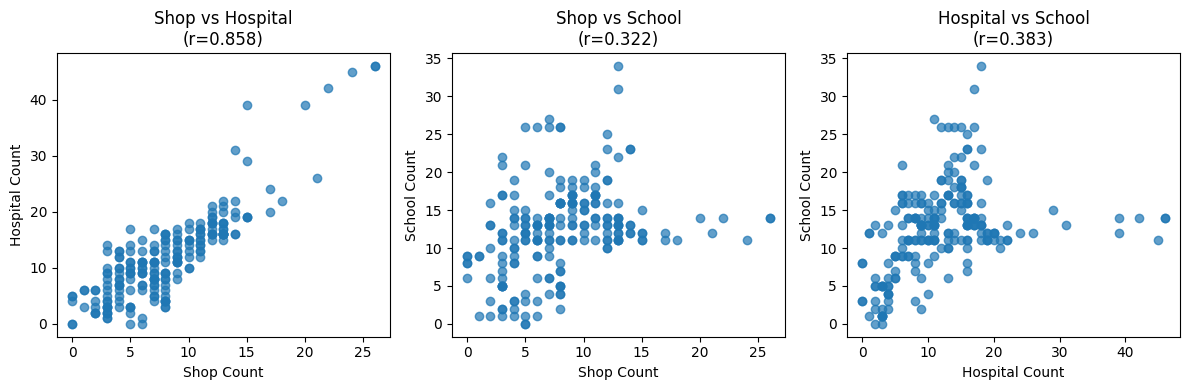

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Shop vs Hospital
axes[0].scatter(df["shop_related_count"], df["hospital_related_count"], alpha=0.7)
axes[0].set_xlabel("Shop Count")
axes[0].set_ylabel("Hospital Count")
axes[0].set_title(f"Shop vs Hospital\n(r={r_shop_hospital})")

# Shop vs School
axes[1].scatter(df["shop_related_count"], df["school_related_count"], alpha=0.7)
axes[1].set_xlabel("Shop Count")
axes[1].set_ylabel("School Count")
axes[1].set_title(f"Shop vs School\n(r={r_school_shop})")

# Hospital vs School
axes[2].scatter(df["hospital_related_count"], df["school_related_count"], alpha=0.7)
axes[2].set_xlabel("Hospital Count")
axes[2].set_ylabel("School Count")
axes[2].set_title(f"Hospital vs School\n(r={r_hospital_school})")

plt.savefig(SAVE_DIR / "pearson_coefficients_scatterplot.png")
plt.tight_layout()
plt.show()
plt.close()

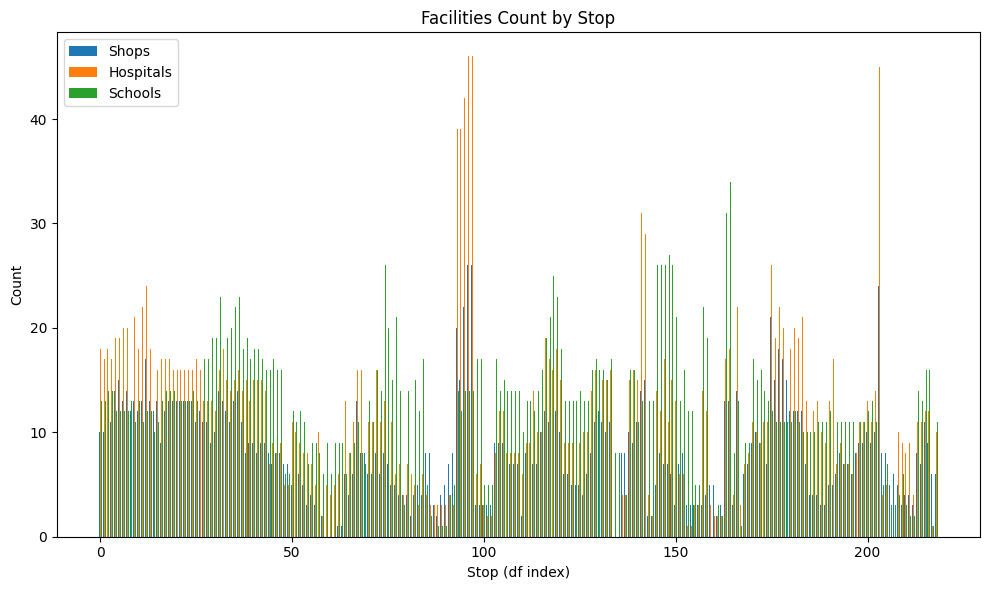

In [96]:
fig, ax = plt.subplots(figsize=(10, 6))

width = 0.25
df_indices = range(len(df))

ax.bar([i - width for i in df_indices], df["shop_related_count"], width, label="Shops")
ax.bar(df_indices, df["hospital_related_count"], width, label="Hospitals")
ax.bar(
    [i + width for i in df_indices], df["school_related_count"], width, label="Schools"
)

ax.set_xlabel("Stop (df index)")
ax.set_ylabel("Count")
ax.set_title("Facilities Count by Stop")
ax.legend()

plt.savefig(SAVE_DIR / "facilities_count_by_stop.png")
plt.tight_layout()
plt.show()